# 🤖 Class 11.3 — ML on Time Series: Lag Features & RandomForest
### 301 – ML Techniques | Week 11

**Learning Goals:** Create lag features, rolling statistics, calendar features. Train RandomForestRegressor on bike share data. Compare MAE vs Holt-Winters baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
print('✅ Ready')
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

✅ Ready


In [2]:
# Daily bike share data (synthetic based on Capital Bikeshare patterns)
np.random.seed(42)
n = 365 * 2  # 2 years daily
dates = pd.date_range('2022-01-01', periods=n, freq='D')

base   = 3000
trend  = np.linspace(0, 500, n)
weekly = 600 * np.sin(2*np.pi*np.arange(n)/7)
annual = 1200 * np.sin(2*np.pi*np.arange(n)/365 - np.pi/2)
noise  = np.random.normal(0, 150, n)
bikes  = pd.Series((base + trend + weekly + annual + noise).clip(100), index=dates, name='Rentals')
print(f'Bike rentals: {n} days, {bikes.mean():.0f} avg daily rentals')

Bike rentals: 730 days, 3249 avg daily rentals


In [3]:
# Feature engineering — creating lag and rolling features
df = pd.DataFrame({'y': bikes})

# Lag features: yesterday's value, 7 days ago, 14 days ago
df['lag_1']  = df['y'].shift(1)
df['lag_7']  = df['y'].shift(7)
df['lag_14'] = df['y'].shift(14)

# Rolling statistics
df['roll_mean_7']  = df['y'].shift(1).rolling(7).mean()
df['roll_std_7']   = df['y'].shift(1).rolling(7).std()
df['roll_mean_30'] = df['y'].shift(1).rolling(30).mean()

# Calendar features using .dt accessor
df['dayofweek'] = df.index.dayofweek     # 0=Monday, 6=Sunday
df['month']     = df.index.month
df['quarter']   = df.index.quarter
df['is_weekend']= (df.index.dayofweek >= 5).astype(int)

df = df.dropna()  # drop rows with NaN from lags/rolling

print(f'Feature matrix shape: {df.shape}')
print('Features:', list(df.columns))

Feature matrix shape: (700, 11)
Features: ['y', 'lag_1', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'roll_mean_30', 'dayofweek', 'month', 'quarter', 'is_weekend']


RandomForest MAE: 171 rentals/day


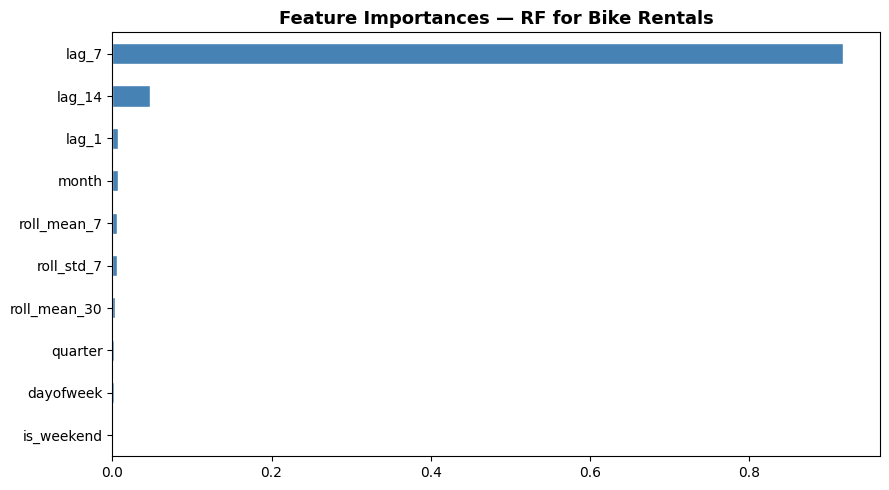

Most important feature: lag_7


In [4]:
# Chronological split
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

feature_cols = [c for c in df.columns if c != 'y']
X_train, y_train = train_df[feature_cols], train_df['y']
X_test,  y_test  = test_df[feature_cols],  test_df['y']

# Train RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred)
print(f'RandomForest MAE: {mae_rf:.0f} rentals/day')

# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importances — RF for Bike Rentals', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


print('Most important feature:', importances.index[-1])

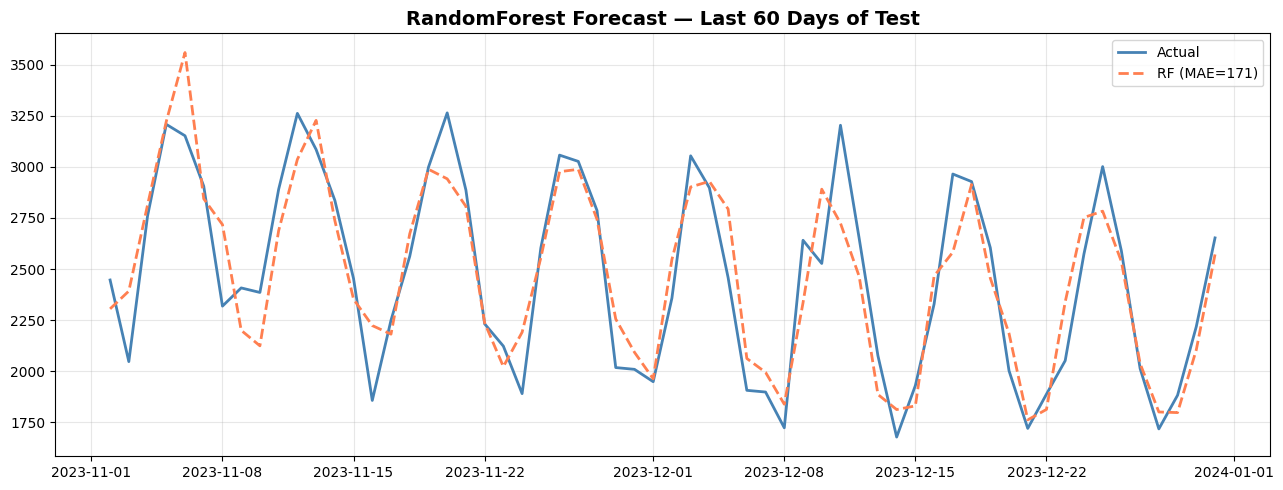

In [5]:
# Plot forecast vs actual
plt.figure(figsize=(13, 5))
plt.plot(test_df.index[-60:], y_test.values[-60:],  color='steelblue', linewidth=2, label='Actual')
plt.plot(test_df.index[-60:], y_pred[-60:],           color='coral',     linewidth=2, linestyle='--', label=f'RF (MAE={mae_rf:.0f})')
plt.title('RandomForest Forecast — Last 60 Days of Test', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## ✅ Complete!

- **Lag features**: convert TS into tabular format — the key trick
- **Rolling stats**: capture short and long-term patterns
- **Calendar features**: day of week, month, is_weekend — powerful for human behaviour
- **ALWAYS shift lag features by ≥1**: using today to predict today = leakage!